In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [22]:
# Vectorized (per-step) discrete-time delta hedging (pricing vol vs realized vol)
import numpy as np
from scipy.stats import norm

def simulate_delta_hedge_paths(
    S0=100.0,
    K=100.0,
    r=0.02,
    sigma_real=0.20,
    sigma_imp=None,
    T=1.0,
    n_steps=390*5,  # number of hedge rebalances (time intervals). There will be n_steps price increments.
    n_paths=10000,
    seed=None,
    include_decomposition=True,
    transaction_cost_bps=0.0,
):
    """Discrete delta hedging for a long European call (long option, dynamically hedged with underlying).

    This version corrects two issues common in ad‑hoc implementations:
      1. Ensures EXACTLY n_steps price increments reaching maturity (previous draft missed final increment).
      2. Provides both cash-account P/L (self‑financing) AND the textbook discrete replication error:
           replication_value = call_price_0 + Σ_{i=1..n_steps} Δ_{i-1} * (S_i - S_{i-1})
           replication_error = replication_value - payoff

    Components returned now map as:
      payoff_component           = payoff - premium
      hedge_trading_component    = Σ Δ_{i-1} dS  (discrete realized risk / gamma harvest term)
      financing_component        = cumulative interest accrued on cash account
      transaction_cost_component = negative cost impact (sum of costs)

    Net P/L identity (up to numerical noise & discretization):
        pnl  ≈ payoff_component + hedge_trading_component + financing_component + transaction_cost_component

    Additional returned values:
      replication_value  : premium + Σ Δ_{i-1} dS
      replication_error  : replication_value - payoff   (NOT centered)
      hedging_error      : replication_error - mean(replication_error) (centered, for histogram symmetry diagnostics)

    Parameters
    ----------
    sigma_real : float
        Used to generate the underlying path (realized vol).
    sigma_imp : float | None
        Used for pricing & deltas. If None defaults to sigma_real (pure replication test).
    transaction_cost_bps : float
        Proportional cost (bps of notional |Δ|*S) applied to every trade including initial hedge & final liquidation.
    n_steps : int
        Number of hedge intervals (there will be n_steps increments & n_steps re-hedges except none after maturity).

    Returns
    -------
    If include_decomposition: dict with keys described above. Otherwise (n_paths,) pnl array.
    """
    sigma_imp = sigma_real if sigma_imp is None else sigma_imp

    rng = np.random.default_rng(seed)
    dt = T / n_steps

    # Initial price & delta
    sqrt_T = np.sqrt(T)
    d1_0 = (np.log(S0 / K) + (r + 0.5 * sigma_imp**2) * T) / (sigma_imp * sqrt_T)
    d2_0 = d1_0 - sigma_imp * sqrt_T
    call_premium = S0 * norm.cdf(d1_0) - K * np.exp(-r * T) * norm.cdf(d2_0)
    delta0 = norm.cdf(d1_0)

    # State
    S = np.full(n_paths, S0)
    cash = -np.full(n_paths, call_premium)  # paid premium
    stock = np.zeros(n_paths)

    # Components
    hedge_risk_pnl = np.zeros(n_paths) if include_decomposition else None  # Σ Δ_{prev} dS
    financing = np.zeros(n_paths) if include_decomposition else None
    trans_costs = np.zeros(n_paths) if include_decomposition else None

    # Initial hedge (trade to delta0)
    if delta0 != 0.0:
        notional0 = delta0 * S0
        stock[:] = delta0
        cash -= notional0
        if transaction_cost_bps > 0.0:
            tc0 = transaction_cost_bps * 1e-4 * abs(notional0)
            cash -= tc0
            if include_decomposition:
                trans_costs -= tc0

    prev_delta = delta0

    # Pre-generate shocks for exact n_steps increments
    Z = rng.standard_normal((n_steps, n_paths))
    drift = (r - 0.5 * sigma_real**2) * dt
    vol_step = sigma_real * np.sqrt(dt)

    for step in range(1, n_steps + 1):  # 1..n_steps inclusive
        # Advance price
        S_prev = S.copy()
        S *= np.exp(drift + vol_step * Z[step - 1])
        dS = S - S_prev

        # Realized delta exposure P/L using PREVIOUS delta
        if include_decomposition:
            hedge_risk_pnl += prev_delta * dS

        # Accrue financing on cash for this interval
        if include_decomposition:
            old_cash = cash.copy()
        cash *= np.exp(r * dt)
        if include_decomposition:
            financing += (cash - old_cash)

        # If maturity reached, stop (no re-hedge after final price move)
        if step == n_steps:
            break

        # Time to maturity after this increment
        t_curr = step * dt
        tau = T - t_curr
        sqrt_tau = np.sqrt(tau)
        d1 = (np.log(S / K) + (r + 0.5 * sigma_imp**2) * tau) / (sigma_imp * sqrt_tau)
        new_delta = norm.cdf(d1)
        trade = new_delta - prev_delta
        if np.any(trade != 0.0):
            trade_notional = trade * S
            cash -= trade_notional
            if transaction_cost_bps > 0.0:
                tc = transaction_cost_bps * 1e-4 * np.abs(trade_notional)
                cash -= tc
                if include_decomposition:
                    trans_costs -= tc
            stock += trade  # new position = old + trade
        prev_delta = new_delta  # for next iteration

    # Maturity payoff & liquidation (liquidate any remaining delta exposure)
    payoff = np.maximum(S - K, 0.0)
    if np.any(stock != 0.0):
        liquid_notional = stock * S
        cash += liquid_notional
        if transaction_cost_bps > 0.0:
            tc = transaction_cost_bps * 1e-4 * np.abs(liquid_notional)
            cash -= tc
            if include_decomposition:
                trans_costs -= tc
        stock[:] = 0.0

    pnl = cash + payoff

    if not include_decomposition:
        return pnl

    payoff_component = payoff - call_premium
    # By integration by parts: premium + Σ Δ_{prev} dS is replication value
    replication_value = call_premium + hedge_risk_pnl
    replication_error = replication_value - payoff
    hedging_error = replication_error - replication_error.mean()  # centered for histogram symmetry

    result = {
        'pnl': pnl,
        'payoff_component': payoff_component,
        'hedge_trading_component': hedge_risk_pnl,  # now explicitly Σ Δ_{prev} dS
        'financing_component': financing,
        'transaction_cost_component': trans_costs,
        'call_premium': call_premium,
        'replication_value': replication_value,
        'replication_error': replication_error,      # uncentered
        'hedging_error': hedging_error,              # centered
        'initial_delta': delta0,
        'sigma_real': sigma_real,
        'sigma_imp': sigma_imp,
        'final_delta': stock.copy(),
    }
    return result

# Gamma Scalping / Delta Hedging Diagnostics Plots

The next cells generate:
1. P/L distribution: replication (sigma_real = sigma_imp) vs mispricing (sigma_real > sigma_imp).
2. Component mean bar chart: payoff-premium, hedge trading, financing, transaction costs.
3. Re-hedge frequency sweep: effect of number of steps on mean P/L and average transaction cost.

Adjust parameters at the top of the data prep cell to explore scenarios (vols, costs, paths).

In [23]:
# Scenario parameters (aligned with basic_options replication example)
S0 = 1.0
K = 1.0
r = 0
T = 1.0
sigma_replication = 1.0  # both realized & implied
# Disable mispricing by setting mis vols equal (will skip plotting mispricing unless changed later)
sigma_real_mis = sigma_replication
sigma_imp_mis = sigma_replication
transaction_cost_bps = 0
n_paths = 100000
n_steps = 1000  # match basic_options n
seed = 12345  # fixed seed for reproducibility

# Replication (no mispricing)
rep = simulate_delta_hedge_paths(
    S0=S0, K=K, r=r, sigma_real=sigma_replication, sigma_imp=sigma_replication,
    T=T, n_steps=n_steps, n_paths=n_paths, seed=seed,
    include_decomposition=True, transaction_cost_bps=transaction_cost_bps
)

rep_mean_pnl = rep['pnl'].mean()

print(f"Replication mean P/L (should be near 0): {rep_mean_pnl:.6f}")
print(f"Replication std: {rep['pnl'].std():.6f}")

Replication mean P/L (should be near 0): -0.011145
Replication std: 2.225671


In [24]:
# Mispricing scenario (only computed if vols differ)
sigma_imp_mis = 0.1
sigma_real_mis = 0.2
compute_mispricing = (sigma_real_mis != sigma_imp_mis)
if compute_mispricing:
    mis = simulate_delta_hedge_paths(
        S0=S0, K=K, r=r, sigma_real=sigma_real_mis, sigma_imp=sigma_imp_mis,
        T=T, n_steps=n_steps, n_paths=n_paths, seed=seed+1 if seed is not None else None,
        include_decomposition=True, transaction_cost_bps=transaction_cost_bps
    )
    component_means_mis = {
        'payoff-premium': mis['payoff_component'].mean(),
        'hedge': mis['hedge_trading_component'].mean(),
        'financing': mis['financing_component'].mean(),
        'tx_costs': mis['transaction_cost_component'].mean(),
        'net': mis['pnl'].mean(),
    }
else:
    component_means_mis = {
        'payoff-premium': 0.0,
        'hedge': 0.0,
        'financing': 0.0,
        'tx_costs': 0.0,
        'net': 0.0,
    }

In [25]:
component_means_mis

{'payoff-premium': np.float64(0.03882191451483402),
 'hedge': np.float64(-0.001036394504479846),
 'financing': np.float64(0.0),
 'tx_costs': np.float64(0.0),
 'net': np.float64(0.03778552001035418)}

In [26]:
# Diagnostic: replication error (uncentered) & stats
replication_error = rep['replication_error']
print(f"Replication error mean (discrete bias): {replication_error.mean():.6e}")
print(f"Replication error std: {replication_error.std():.6f}")
print(f"Net P/L mean: {rep['pnl'].mean():.6e}  (should match payoff_component + hedge + financing + tx)")

Replication error mean (discrete bias): -1.262829e-05
Replication error std: 0.010246
Net P/L mean: -1.114535e-02  (should match payoff_component + hedge + financing + tx)


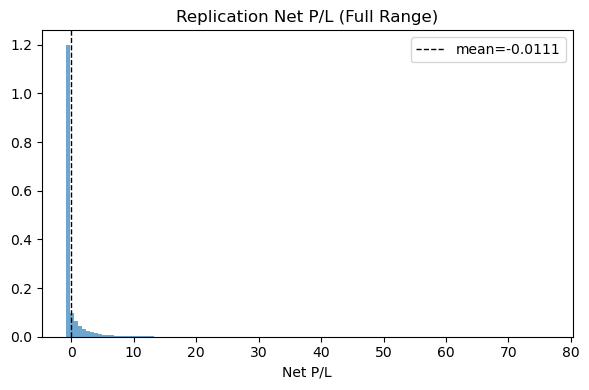

In [27]:
# Raw histogram (previous version accidentally cropped to a negative slice)
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(rep['pnl'], bins=120, density=True, color='tab:blue', alpha=0.65)
mean_pnl = rep['pnl'].mean()
ax.axvline(mean_pnl, color='k', ls='--', lw=1, label=f"mean={mean_pnl:.4f}")
ax.set_title('Replication Net P/L (Full Range)')
ax.set_xlabel('Net P/L')
ax.legend()
plt.tight_layout()

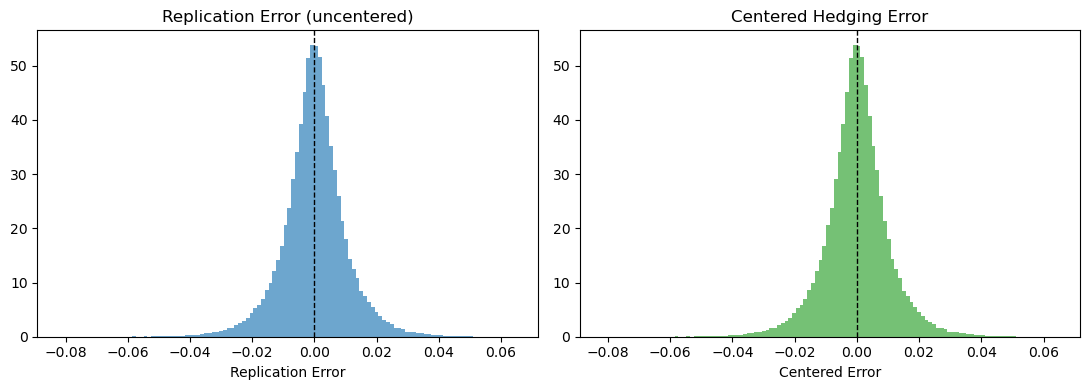

In [28]:
# Plot replication error (uncentered) and centered hedging error
import matplotlib.pyplot as plt
replication_error = rep['replication_error']
hedging_error = rep['hedging_error']

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].hist(replication_error, bins=120, color='tab:blue', alpha=0.65, density=True)
ax[0].axvline(replication_error.mean(), color='k', ls='--', lw=1)
ax[0].set_title('Replication Error (uncentered)')
ax[0].set_xlabel('Replication Error')

ax[1].hist(hedging_error, bins=120, color='tab:green', alpha=0.65, density=True)
ax[1].axvline(0, color='k', ls='--', lw=1)
ax[1].set_title('Centered Hedging Error')
ax[1].set_xlabel('Centered Error')
plt.tight_layout()

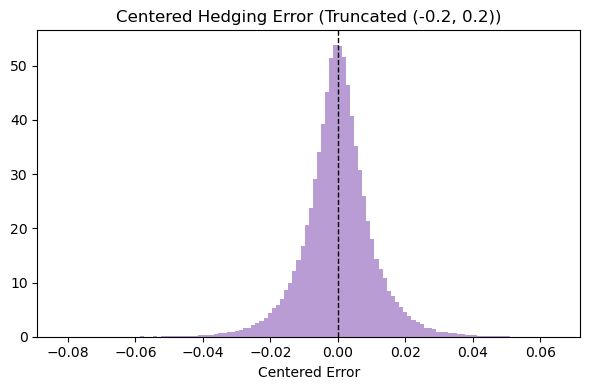

In [29]:
# (Optional) Truncated view of centered hedging error
trunc_range = (-0.2, 0.2)
mask = (hedging_error >= trunc_range[0]) & (hedging_error <= trunc_range[1])
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(hedging_error[mask], bins=120, color='tab:purple', alpha=0.65, density=True)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_title(f'Centered Hedging Error (Truncated {trunc_range})')
ax.set_xlabel('Centered Error')
plt.tight_layout()

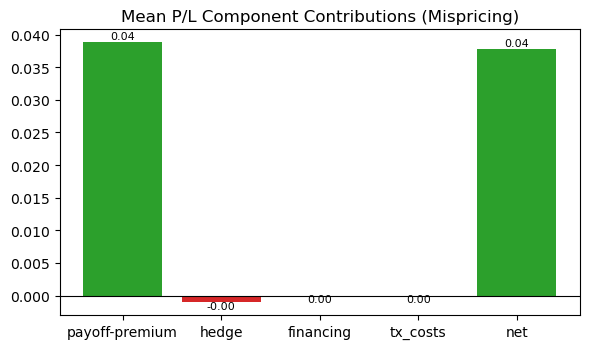

In [30]:
# Bar chart of mean component contributions (mispricing scenario)
means = component_means_mis
labels = list(means.keys())
vals = [means[k] for k in labels]
fig, ax = plt.subplots(figsize=(6,3.6))
colors = ['tab:green' if v>0 else 'tab:red' for v in vals]
ax.bar(labels, vals, color=colors)
ax.set_title('Mean P/L Component Contributions (Mispricing)')
ax.axhline(0, color='black', lw=0.8)
for i,v in enumerate(vals):
    ax.text(i, v + (0.005* (max(vals)-min(vals))) , f"{v:.2f}", ha='center', va='bottom' if v>0 else 'top', fontsize=8)
plt.tight_layout()

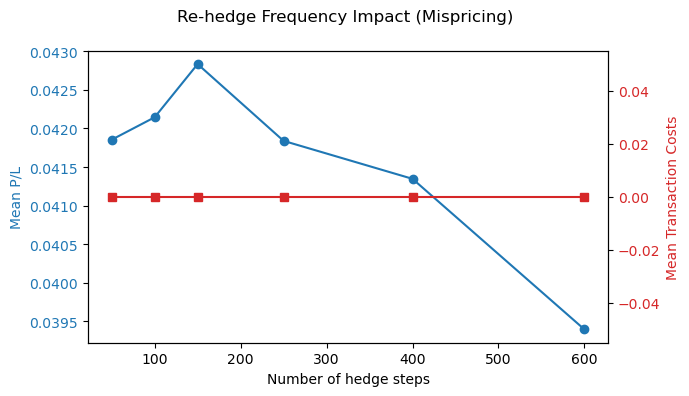

In [31]:
# Re-hedge frequency sweep (mispricing scenario)
frequencies = [50, 100, 150, 250, 400, 600]
mean_pnl = []
mean_cost = []
for steps in frequencies:
    sweep_res = simulate_delta_hedge_paths(
        S0=S0, K=K, r=r, sigma_real=sigma_real_mis, sigma_imp=sigma_imp_mis,
        T=T, n_steps=steps, n_paths=15000, seed=999, include_decomposition=True,
        transaction_cost_bps=transaction_cost_bps
    )
    mean_pnl.append(sweep_res['pnl'].mean())
    mean_cost.append(sweep_res['transaction_cost_component'].mean())

fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(frequencies, mean_pnl, marker='o', color='tab:blue', label='Mean P/L')
ax1.set_xlabel('Number of hedge steps')
ax1.set_ylabel('Mean P/L', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(frequencies, mean_cost, marker='s', color='tab:red', label='Mean Tx Costs')
ax2.set_ylabel('Mean Transaction Costs', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
fig.suptitle('Re-hedge Frequency Impact (Mispricing)')
fig.tight_layout()